In [ ]:
import seaborn as sb
import pingouin as pg
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib as mpl
import matplotlib.pyplot as plt
import sys
sys.path.extend(['/Users/amonast/Documents/GitHub/Engram_2P/Engram_2P/utilities'])
from traces import ridge_plot,normalize_eventtimes,get_traces
import matplotlib as mpl
from matplotlib import rcParams
from matplotlib import font_manager
plt.style.use('/Users/amonast/Documents/GitHub/Amy_Reviews/paper_style.mplstyle')

savepath = '/Users/amonast/BOSTON UNIVERSITY Dropbox/Amy Monasterio/Manuscripts/Engram2P/Figures/RevisionFigures/Figure2-Supp3/plots'

/Users/amonast/opt/anaconda3/envs/caiman/lib/python3.10/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.6.1.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


# Load and process data

In [4]:
def calculate_deciles_ani(ani_df):
    animal = ani_df['Animal'].values[0]
    ani_df['Decile'],bins=pd.qcut(ani_df['Event Rate'], 10,labels=False,retbins=True)
    ani_df['Decile']=ani_df['Decile']+1
    decile_ptagged = [ani_df.loc[(ani_df['Decile']==d)&(ani_df['Population']=='Tagged')].shape[0] 
                  / ani_df.loc[(ani_df['Decile']==d)].shape[0] for d in np.unique(ani_df['Decile'])]
    decile_means = [ani_df['Event Rate'].loc[ani_df['Decile']==d].mean() for d in np.unique(ani_df['Decile'])]
    df = pd.DataFrame()
    df['Animal']=[animal]*10
    df['Decile Mean Rates']=decile_means
    df['P(Tagged)']=decile_ptagged
    return df,ani_df,bins

df = pd.read_csv('/Users/amonast/Documents/GitHub/Amy_Reviews/data/rates_all_mice_df_weight_5std_filt.csv')
info = pd.read_csv('/Volumes/AM_SSD1/Spont2P/Data_info.csv')
df = df.drop(['Unnamed: 0'],axis=1)
deciles = pd.DataFrame()
for ani in ['992N']:
    ani_df = df.loc[(df['Animal']==ani)&(df['Session']=='Baseline')].reset_index(drop=True)
    group = info['Group'].loc[info['Animal']==ani].values[0]
    df_ani,cells_df,bins= calculate_deciles_ani(ani_df)
cells_df['Population'] = cells_df.Population.map({'Tagged':'Engram','Non-Tagged':'Non-engram'})

# Histograms

Text(0.5, 0, 'Calcium Event Rate (Hz)')

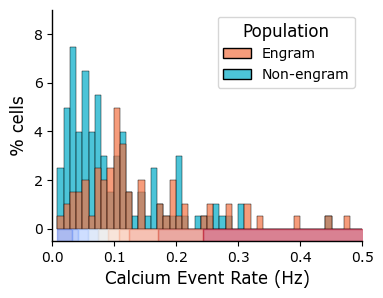

In [5]:

#plt.vlines(df_ani['Decile Mean Rates'],0,14,color='r')
cmap = mpl.cm.get_cmap('coolwarm')
colors = np.linspace(0,1,11)
fig,ax=plt.subplots(figsize=(4,3))
sb.histplot(data=cells_df,x='Event Rate',hue='Population',hue_order=['Engram','Non-engram'],multiple='layer',
        binwidth=.01,palette=['#F37243','#00ABC8'],kde=False,log_scale=False,stat='percent',alpha=.7,common_norm=True)
for i in np.arange(1,len(bins)):
    x0 = np.linspace(bins[i-1],bins[i])
    plt.fill_between(x0,0,-.5, alpha=0.5,color=cmap(colors[i]))
sb.despine()
plt.ylabel('% cells')
plt.xlim(0,.5)
plt.ylim(-.5,9)
plt.xlabel('Calcium Event Rate (Hz)')
#plt.savefig('Deciles_992N_D0_shadedhist_.svg',transparent=True,dpi=300)

/var/folders/4k/5kmnnrq94j136038_jy_4twc0000gq/T/ipykernel_96611/164122861.py:12: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0,.7)


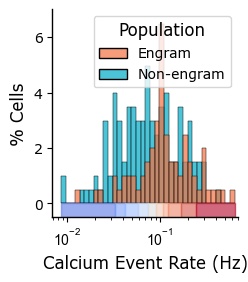

In [6]:
#plt.vlines(df_ani['Decile Mean Rates'],0,14,color='r')
cmap = mpl.cm.get_cmap('coolwarm')
colors = np.linspace(0,1,11)
fig,ax=plt.subplots(figsize=(2.4,2.7))
sb.histplot(data=cells_df,x='Event Rate',hue='Population',hue_order=['Engram','Non-engram'],multiple='layer',legend=True,
        binwidth=.05,palette=['#F37243','#00ABC8'],kde=False,log_scale=True,stat='percent',alpha=.7,common_norm=True,ax=ax)
handles, labels = ax.get_legend_handles_labels()
for i in np.arange(1,len(bins)):
    x0 = np.linspace(bins[i-1],bins[i])
    plt.fill_between(x0,0,-.5, alpha=0.6,color=cmap(colors[i]))
plt.ylabel('% Cells')
plt.xlim(0,.7)
plt.ylim(-.5,7)
plt.xlabel('Calcium Event Rate (Hz)')
for label in ax.get_xticklabels():
    label.set_fontproperties(font_manager.FontProperties(family='Arial'))
sb.despine()
#plt.savefig('Deciles_992N_D0_shadedhist_log.svg',transparent=True,dpi=300)

Text(0.5, 0, 'Calcium Event Rate (Hz)')

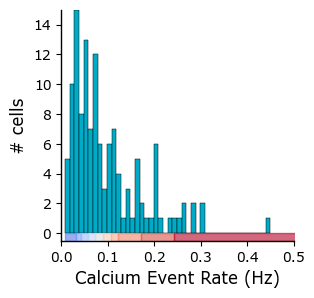

In [7]:
import matplotlib as mpl
#plt.vlines(df_ani['Decile Mean Rates'],0,14,color='r')
colors = np.linspace(0,1,11)
fig,ax=plt.subplots(figsize=(3,3))

sb.histplot(data=cells_df.loc[cells_df.Population=='Non-engram'],x='Event Rate',multiple='layer',binwidth=.01,color='#00ABC8',kde=False,log_scale=False,stat='count',alpha=1)
#sb.kdeplot(data=cells_df,x='Event Rate',hue='Population',palette=['#00ABC8','#F37243'])
for i in np.arange(1,len(bins)):
    x0 = np.linspace(bins[i-1],bins[i])
    plt.fill_between(x0, 0,-.5, alpha=0.6,color=cmap(colors[i]))
sb.despine()
plt.ylabel('# cells')
plt.xlim(0,.5)
plt.ylim(-.5,15)
plt.xlabel('Calcium Event Rate (Hz)')
#plt.savefig('/Deciles_992N_D0_shadedhist_non.svg',transparent=True,dpi=300)

/var/folders/4k/5kmnnrq94j136038_jy_4twc0000gq/T/ipykernel_96611/550310469.py:13: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0,.6)


Text(0.5, 0, 'Calcium Event Rate (Hz)')

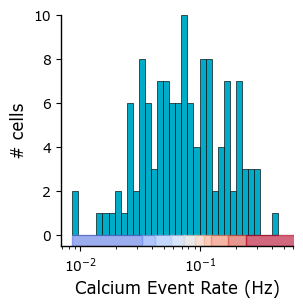

In [8]:
import matplotlib as mpl
#plt.vlines(df_ani['Decile Mean Rates'],0,14,color='r')
colors = np.linspace(0,1,11)
fig,ax=plt.subplots(figsize=(3,3))

sb.histplot(data=cells_df.loc[cells_df.Population=='Non-engram'],x='Event Rate',multiple='layer',binwidth=.05,color='#00ABC8',kde=False,log_scale=True,stat='count',alpha=1)
#sb.kdeplot(data=cells_df,x='Event Rate',hue='Population',palette=['#00ABC8','#F37243'])
for i in np.arange(1,len(bins)):
    x0 = np.linspace(bins[i-1],bins[i])
    plt.fill_between(x0, 0,-.5, alpha=0.6,color=cmap(colors[i]))
sb.despine()
plt.ylabel('# cells')
plt.xlim(0,.6)
plt.ylim(-.5,10)
plt.xlabel('Calcium Event Rate (Hz)')
#plt.savefig('Deciles_992N_D0_shadedhist_non.svg',transparent=True,dpi=300)

Text(0.5, 0, 'Calcium Event Rate (Hz)')

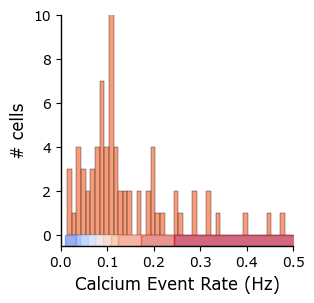

In [9]:
import matplotlib as mpl
#plt.vlines(df_ani['Decile Mean Rates'],0,14,color='r')
colors = np.linspace(0,1,11)
fig,ax=plt.subplots(figsize=(3,3))
sb.histplot(data=cells_df.loc[cells_df.Population=='Engram'],x='Event Rate',multiple='layer',binwidth=.01,color='#F37243',kde=False,log_scale=False,stat='count',alpha=.7)
for i in np.arange(1,len(bins)):
    x0 = np.linspace(bins[i-1],bins[i])
    plt.fill_between(x0, 0,-.5, alpha=.6,color=cmap(colors[i]))
#sb.kdeplot(data=cells_df,x='Event Rate',hue='Population',palette=['#00ABC8','#F37243'])
sb.despine()
plt.ylabel('# cells')
plt.xlim(0,.5)
plt.ylim(-.5,10)
plt.xlabel('Calcium Event Rate (Hz)')
#plt.savefig('Deciles_992N_D0_shadedhist_tag.svg',transparent=True,dpi=300)

/var/folders/4k/5kmnnrq94j136038_jy_4twc0000gq/T/ipykernel_96611/668835808.py:12: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0,.5)


Text(0.5, 0, 'Calcium Event Rate (Hz)')

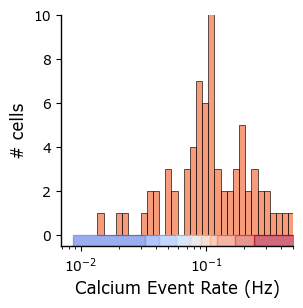

In [10]:
import matplotlib as mpl
#plt.vlines(df_ani['Decile Mean Rates'],0,14,color='r')
colors = np.linspace(0,1,11)
fig,ax=plt.subplots(figsize=(3,3))
sb.histplot(data=cells_df.loc[cells_df.Population=='Engram'],x='Event Rate',multiple='layer',binwidth=.05,color='#F37243',kde=False,log_scale=True,stat='count',alpha=.7)
for i in np.arange(1,len(bins)):
    x0 = np.linspace(bins[i-1],bins[i])
    plt.fill_between(x0, 0,-.5, alpha=.6,color=cmap(colors[i]))
#sb.kdeplot(data=cells_df,x='Event Rate',hue='Population',palette=['#00ABC8','#F37243'])
sb.despine()
plt.ylabel('# cells')
plt.xlim(0,.5)
plt.ylim(-.5,10)
plt.xlabel('Calcium Event Rate (Hz)')
#plt.savefig('Deciles_992N_D0_shadedhist_tag.svg',transparent=True,dpi=300)

# Figure 3A


/var/folders/4k/5kmnnrq94j136038_jy_4twc0000gq/T/ipykernel_96611/394112315.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.stripplot(data=cells_df,y='Event Rate',x='Decile',


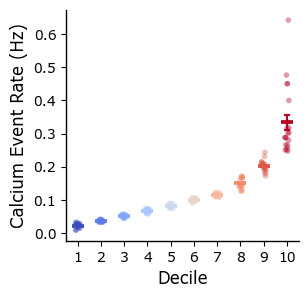

In [13]:

colors = np.linspace(0,1,10)
fig,ax=plt.subplots(figsize=(3,3))
sb.pointplot(data=cells_df,y='Event Rate',x='Decile',
             errorbar='se',hue='Decile',
             palette=[cmap(colors[i]) for i in range(len(colors))],
             markers=['_']*10,
             ax=ax,
             err_kws={'linewidth':1.5},
             capsize=.2)
sb.stripplot(data=cells_df,y='Event Rate',x='Decile',
             palette=[cmap(colors[i]) for i in range(len(colors))],alpha=.4,size=4,ax=ax)
plt.ylabel('Calcium Event Rate (Hz)')
plt.xlabel('Decile')
sb.despine()
plt.legend().remove()
plt.savefig('Fig3A_scatterplot.svg',transparent=True)


# Traces

In [ ]:
import sys
sys.path.extend(['/Users/amonast/Documents/GitHub/Engram_2P/Engram_2P'])
base_dir = '/Volumes/AM_SSD1/Spont2P'
file_key =  '/Volumes/AM_SSD1/Spont2P/Data_info.csv'
ani='992N'
fov='FOV2'
dff, ev, etimes, est = get_traces(ani, fov, 'Baseline', file_key, base_dir)
tmin,tmax=0,40000

deconvolution file: /Volumes/AM_SSD1/Spont2P/deconvolution/deconvolution_results/deconv_results_min5/992N_TSeries-11162021-043_cnmfresults_152022_183517_dff_l0deconv.pkl


In [15]:
qi=[cells_df.Baseline.loc[cells_df.Decile==d].values for d in np.arange(1,11)]
#inds = [np.random.choice(qi[i]) for i in range(len(qi))]
#np.save(f"/Users/amonast/Dropbox (BOSTON UNIVERSITY)/Manuscripts/Engram2P/Figures/Figure3/Deciles_{ani}_D0_traces_cells.npy",inds)
inds = np.load(f"/Users/amonast/Dropbox (BOSTON UNIVERSITY)/Manuscripts/Engram2P/Figures/bioRxiv/Figure2_allocation/Deciles_{ani}_D0_traces_cells.npy")
print(inds)

[108 129 220  66 112  14  93 203 191 109]


 # Figure 3C

In [18]:
from scipy.ndimage import gaussian_filter1d

text color


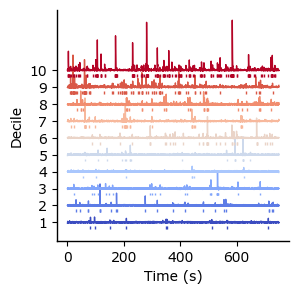

In [25]:
tmin,tmax=0*30,750*30
times = np.linspace(0,(tmax-tmin)/30,tmax-tmin)
events = [normalize_eventtimes(etimes[ii],tmin,tmax) for ii in inds]
smoothed =gaussian_filter1d(dff[inds,tmin:tmax],sigma=3)
fig,ax=plt.subplots(figsize=(3,3))
plot_colors = [cmap(colors[i]) for i in np.arange(0,10)]
ridge_plot(smoothed,times,trace_spacing=3,
           ytick_spacing=1,title=None,
           color=plot_colors,
           text_color='k',alpha= 1,line_width=1
           ,ax = ax,
           eventtimes=events,event_color='match')
plt.ylabel('Decile',size=10)
plt.xlabel('Time (s)',size=10)
plt.savefig(f'Figure3C_traces.svg',transparent=True)

/var/folders/4k/5kmnnrq94j136038_jy_4twc0000gq/T/ipykernel_96611/2610129904.py:10: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


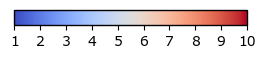

In [33]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

cmap = mpl.cm.get_cmap('coolwarm')
norm = mpl.colors.Normalize(vmin=1, vmax=10)
fig, ax = plt.subplots(figsize=(3,.2))
cb = mpl.colorbar.ColorbarBase(ax, cmap=cmap, norm=norm, orientation='horizontal')
cb.set_ticks(np.arange(1, 11, 1))
plt.tight_layout()
plt.savefig('Fig3A_colorbar.svg',transparent=True)